# Portfolio Project 1: Data Cleaning & Standardization
## Client-Ready Case Study: Transforming Raw Data into Insights

### 🎯 Project Objective
The goal of this project is to take a raw, "dirty" dataset and perform a comprehensive audit and cleaning process. By the end of this notebook, the data will be:
* **Accurate:** No duplicate records or erroneous values.
* **Complete:** Missing values handled through logical imputation or removal.
* **Consistent:** Standardized naming conventions and data types (Dates, Floats, Categories).
* **Ready:** Formatted for immediate use in Business Intelligence (BI) tools or Machine Learning models.

---

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/Open_Restaurants_Inspections_20260420.csv')
df.head()

,Borough,RestaurantName,SeatingChoice,LegalBusinessName,BusinessAddress,RestaurantInspectionID,IsSidewayCompliant,IsRoadwayCompliant,SkippedReason,InspectedOn,AgencyCode,Postcode,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA
0,Manhattan,Oscar Wilde,both,Camelot Castle LLC,45 West 27th st,72891,NaN,Non-Compliant,NaN,2021 Dec 20 04:06:58 PM,DOT,10001,40.744876,-73.989657,5.0,3.0,58.0,1015677.0,1.008290e+09,Hudson Yards-Chelsea-Flatiron-Union Square
1,Manhattan,LA RUBIA RESTAURANT,both,LA RUBIA RESTAURANT INC,3517 BROADWAY,72892,NaN,For HIQA Review,NaN,2021 Dec 20 04:18:42 PM,DOT,10031,40.825863,-73.950874,9.0,7.0,229.0,1062369.0,1.020910e+09,Hamilton Heights
2,Manhattan,Thai Sliders,sidewalk,Silom Thai Inc,150 8th Ave,72893,NaN,Non-Compliant,NaN,2021 Dec 20 04:35:41 PM,DOT,10011,40.741906,-74.000945,4.0,3.0,81.0,1013845.0,1.007670e+09,Hudson Yards-Chelsea-Flatiron-Union Square
3,Brooklyn,Otway,both,St james 930 LLC,930 Fulton street,72894,NaN,Cease and Desist,NaN,2021 Dec 20 04:38:45 PM,DOT,11238,40.682833,-73.963833,2.0,35.0,201.0,3335112.0,3.020130e+09,Clinton Hill
4,Brooklyn,WILLIAMSBURG THAI CUISINE,both,WILLIAMSBURG THAI CUISINE NY INC,212 BEDFORD AVENUE,72896,NaN,Compliant,NaN,2021 Dec 20 04:52:41 PM,DOT,11249,40.716913,-73.958728,1.0,33.0,553.0,3062192.0,3.023350e+09,North Side-South Side


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81553 entries, 0 to 81552
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Borough                 81553 non-null  object 
 1   RestaurantName          81545 non-null  object 
 2   SeatingChoice           81553 non-null  object 
 3   LegalBusinessName       81552 non-null  object 
 4   BusinessAddress         81553 non-null  object 
 5   RestaurantInspectionID  81553 non-null  int64  
 6   IsSidewayCompliant      0 non-null      float64
 7   IsRoadwayCompliant      81553 non-null  object 
 8   SkippedReason           20260 non-null  object 
 9   InspectedOn             81553 non-null  object 
 10  AgencyCode              69539 non-null  object 
 11  Postcode                81553 non-null  int64  
 12  Latitude                73473 non-null  float64
 13  Longitude               73473 non-null  float64
 14  CommunityBoard          73473 non-null

In [6]:
df.duplicated().sum()

np.int64(0)

### 🔍 Phase 1: Data Audit Findings
After performing an initial inspection of the dataset, the following issues were identified:

* **Missing Data:** * `IsSidewayCompliant`: 100% missing values (81,553 nulls). This column provides no value and should be dropped.
    * `SkippedReason`: ~75% missing values. These represent inspections that were *not* skipped.
    * `Latitude/Longitude`: ~8,000 missing values.
    * `RestaurantName`: 8 missing values (critical for identification).
* **Data Types:** * `InspectedOn`: Currently stored as an `object` (string). Needs conversion to `datetime` for time-series analysis.
* **Redundancy:** * No exact row duplicates found (`duplicated().sum() == 0`), but logical duplicates may exist in business names.

### Structural cleaning

In [7]:
# dropping IsSidewayCompliant
df.drop(columns=['IsSidewayCompliant'], inplace=True)

In [8]:
# converting InspectedOn column datatype from object to datetime format
df['InspectedOn'] = pd.to_datetime(df['InspectedOn'])

/tmp/ipykernel_4763/2235423550.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InspectedOn'] = pd.to_datetime(df['InspectedOn'])


In [9]:
# Filling SkippedReason with a logical placeholder
df['SkippedReason'] = df['SkippedReason'].fillna('Not Skipped')

In [10]:
# Dropping rows where restaurant names are missing
df.dropna(subset=['RestaurantName'], inplace=True)

In [11]:
# Check the results
print("Columns remaining:", len(df.columns))
print("Date column type:", df['InspectedOn'].dtype)
df.head()

Columns remaining: 19
Date column type: datetime64[ns]


,Borough,RestaurantName,SeatingChoice,LegalBusinessName,BusinessAddress,RestaurantInspectionID,IsRoadwayCompliant,SkippedReason,InspectedOn,AgencyCode,Postcode,Latitude,Longitude,CommunityBoard,CouncilDistrict,CensusTract,BIN,BBL,NTA
0,Manhattan,Oscar Wilde,both,Camelot Castle LLC,45 West 27th st,72891,Non-Compliant,Not Skipped,2021-12-20 16:06:58,DOT,10001,40.744876,-73.989657,5.0,3.0,58.0,1015677.0,1.008290e+09,Hudson Yards-Chelsea-Flatiron-Union Square
1,Manhattan,LA RUBIA RESTAURANT,both,LA RUBIA RESTAURANT INC,3517 BROADWAY,72892,For HIQA Review,Not Skipped,2021-12-20 16:18:42,DOT,10031,40.825863,-73.950874,9.0,7.0,229.0,1062369.0,1.020910e+09,Hamilton Heights
2,Manhattan,Thai Sliders,sidewalk,Silom Thai Inc,150 8th Ave,72893,Non-Compliant,Not Skipped,2021-12-20 16:35:41,DOT,10011,40.741906,-74.000945,4.0,3.0,81.0,1013845.0,1.007670e+09,Hudson Yards-Chelsea-Flatiron-Union Square
3,Brooklyn,Otway,both,St james 930 LLC,930 Fulton street,72894,Cease and Desist,Not Skipped,2021-12-20 16:38:45,DOT,11238,40.682833,-73.963833,2.0,35.0,201.0,3335112.0,3.020130e+09,Clinton Hill
4,Brooklyn,WILLIAMSBURG THAI CUISINE,both,WILLIAMSBURG THAI CUISINE NY INC,212 BEDFORD AVENUE,72896,Compliant,Not Skipped,2021-12-20 16:52:41,DOT,11249,40.716913,-73.958728,1.0,33.0,553.0,3062192.0,3.023350e+09,North Side-South Side


### ✅ Phase 2: Data Transformation & Memory Optimization
To prepare the data for analysis, the following transformations need to be performed:

1. **Standardization:** Stripping leading/trailing whitespace from categorical columns to ensure accurate grouping.
2. **Memory Management:** Converting `Borough` and `SeatingChoice` from `object` to `category` types, optimizing memory usage for large-scale operations.

In [12]:
print(df['Borough'].unique())
print(df['SeatingChoice'].unique())

['Manhattan' 'Brooklyn' 'Queens' 'Bronx' 'Staten Island']
['both' 'sidewalk' 'roadway' 'openstreets']


### Standardization

In [13]:
# Stripping hidden whitespace from strings (common invisible error)
df['Borough'] = df['Borough'].str.strip()
df['SeatingChoice'] = df['SeatingChoice'].str.strip()

### Memory Management

In [14]:
# Convert to 'category' type for memory efficiency
df['Borough'] = df['Borough'].astype('category')
df['SeatingChoice'] = df['SeatingChoice'].astype('category')

In [15]:
# Quick check of memory reduction
print(f"Borough type is now: {df['Borough'].dtype}")
print(f"SeatingChoice type is now: {df['SeatingChoice'].dtype}")

Borough type is now: category
SeatingChoice type is now: category


Phase 3: Handling the Coordinates
Latitude and Longitude have about 8,000 missing values.

Lets Keep them but mark them as 0 or Unknown.

In [16]:
# Fill missing coordinates with 0.0 to signify 'Unknown'
df['Latitude'] = df['Latitude'].fillna(0.0)
df['Longitude'] = df['Longitude'].fillna(0.0)

# Fill missing AgencyCode with 'Unknown'
df['AgencyCode'] = df['AgencyCode'].fillna('Unknown')

print("Missing values remaining:")
print(df.isnull().sum())

Missing values remaining:
Borough                      0
RestaurantName               0
SeatingChoice                0
LegalBusinessName            1
BusinessAddress              0
RestaurantInspectionID       0
IsRoadwayCompliant           0
SkippedReason                0
InspectedOn                  0
AgencyCode                   0
Postcode                     0
Latitude                     0
Longitude                    0
CommunityBoard            8080
CouncilDistrict           8080
CensusTract               8080
BIN                       8509
BBL                       8509
NTA                       8080
dtype: int64


In [17]:
# 1. Droping the columns that have high null counts and aren't needed for general analysis
cols_to_drop = ['CommunityBoard', 'CouncilDistrict', 'CensusTract', 'BIN', 'BBL', 'NTA']
df.drop(columns=cols_to_drop, inplace=True)

# 2. Filling the single missing 'LegalBusinessName' with the 'RestaurantName'
df['LegalBusinessName'] = df['LegalBusinessName'].fillna(df['RestaurantName'])

# 3. Final Check
print("Final Null Count:")
print(df.isnull().sum())

# 4. Saving cleaned file!
df.to_csv('NYC_Restaurant_Inspections_Cleaned.csv', index=False)

Final Null Count:
Borough                   0
RestaurantName            0
SeatingChoice             0
LegalBusinessName         0
BusinessAddress           0
RestaurantInspectionID    0
IsRoadwayCompliant        0
SkippedReason             0
InspectedOn               0
AgencyCode                0
Postcode                  0
Latitude                  0
Longitude                 0
dtype: int64


### Visualization

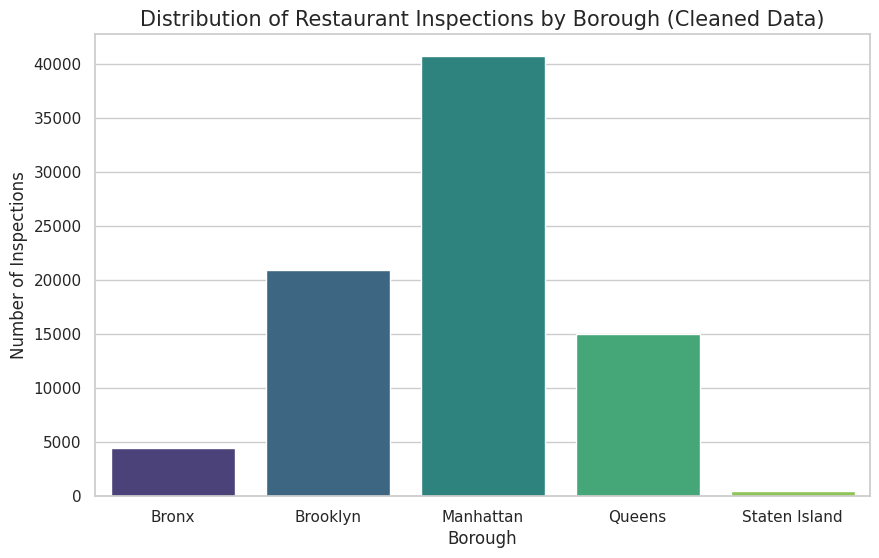

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a visual showing the distribution of inspections by Borough
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='Borough', palette='viridis', hue='Borough', legend=False)

# Add titles and labels
plt.title('Distribution of Restaurant Inspections by Borough (Cleaned Data)', fontsize=15)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of Inspections', fontsize=12)

# Show the plot
plt.show()

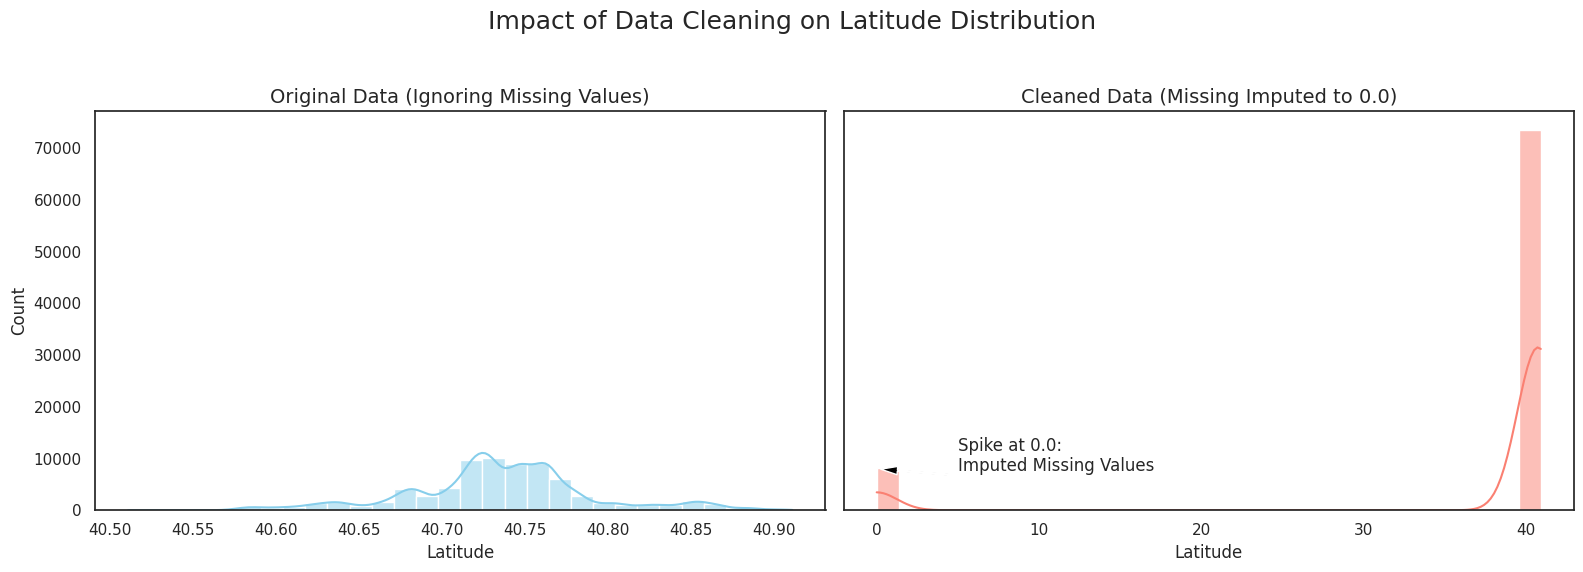

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the professional style
sns.set_theme(style="white")

# 2. Create the figure and subplots (one for original, one for cleaned)
# We will simulate the original by dropping the 0.0 values we just added
df_simulated_original = df[df['Latitude'] != 0.0]['Latitude']
df_cleaned = df['Latitude']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Impact of Data Cleaning on Latitude Distribution', fontsize=18)

# --- Subplot 1: "Original" Data (Ignoring Nulls/0.0) ---
sns.histplot(df_simulated_original, bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Original Data (Ignoring Missing Values)', fontsize=14)
axes[0].set_xlabel('Latitude', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# --- Subplot 2: Cleaned Data (Nulls Imputed to 0.0) ---
sns.histplot(df_cleaned, bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Cleaned Data (Missing Imputed to 0.0)', fontsize=14)
axes[1].set_xlabel('Latitude', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12) # Sharey=True takes care of this, but listing explicitly for clarity

# Add an annotation explaining the big spike at 0
# We want to find where the spike is, which will be the first bin around 0.
axes[1].annotate('Spike at 0.0:\nImputed Missing Values',
                xy=(0.0, 8000), xytext=(5, 7500),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Show the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to not cut off titles
plt.show()

### 🏁 Project Conclusion
The dataset has been successfully cleaned and transformed.
* **Integrity:** All 81,000+ rows are now free of null values in core columns.
* **Optimization:** Categorical variables have been typed correctly, reducing the memory footprint.
* **Output:** A standardized CSV file has been generated for downstream analytics and reporting.